M=5, activation=logistic, CV Error=1796.4900
M=5, activation=tanh, CV Error=1796.5004
M=5, activation=relu, CV Error=21.9261
M=10, activation=logistic, CV Error=1796.5280
M=10, activation=tanh, CV Error=1796.5021
M=10, activation=relu, CV Error=10.2739
M=20, activation=logistic, CV Error=1796.5794
M=20, activation=tanh, CV Error=917.4029
M=20, activation=relu, CV Error=5.8541
M=50, activation=logistic, CV Error=1796.8038
M=50, activation=tanh, CV Error=0.4380
M=50, activation=relu, CV Error=0.0532
M=100, activation=logistic, CV Error=1796.7722
M=100, activation=tanh, CV Error=0.2122
M=100, activation=relu, CV Error=0.0234

Best Hidden Nodes = 100
Best Activation = relu

Training Error = 0.0126429589819234
Test Error = 0.013331981824934294


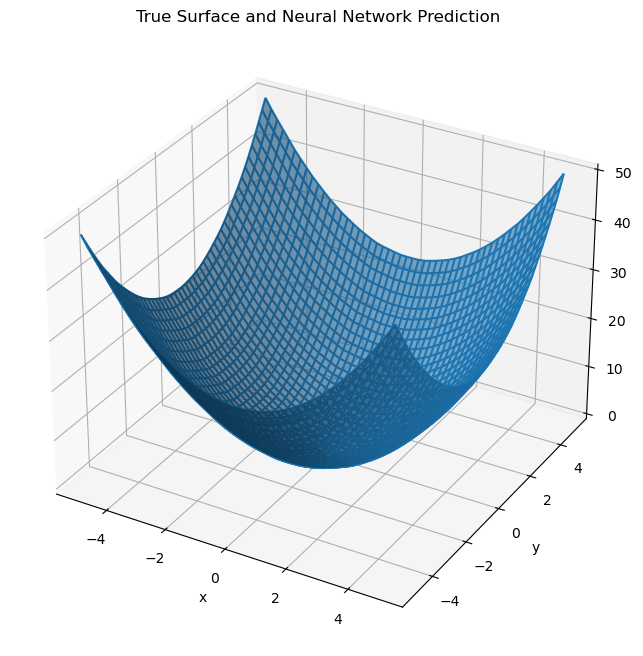

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D

# =====================================================
# (a) Generate Training Data
# =====================================================
np.random.seed(42)

n_train = 10000

# x ~ Uniform([-10,10]^2)
X_train = np.random.uniform(-10, 10, size=(n_train, 2))

# y = ||x||^2 = x1^2 + x2^2
y_train = np.sum(X_train**2, axis=1)

# =====================================================
# (b) 5-Fold Cross Validation
# Hidden nodes M in {5,10,20,50,100}
# Activations = logistic, tanh, relu
# =====================================================

M_values = [5, 10, 20, 50, 100]
activations = ["logistic", "tanh", "relu"]

best_score = float("inf")
best_M = None
best_act = None

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for M in M_values:
    for act in activations:

        model = MLPRegressor(
            hidden_layer_sizes=(M,),
            activation=act,
            max_iter=2000,
            random_state=42
        )

        # Negative MSE -> convert to positive
        scores = -cross_val_score(
            model,
            X_train,
            y_train,
            cv=kf,
            scoring="neg_mean_squared_error"
        )

        avg_score = scores.mean()

        print(f"M={M}, activation={act}, CV Error={avg_score:.4f}")

        if avg_score < best_score:
            best_score = avg_score
            best_M = M
            best_act = act

print("\nBest Hidden Nodes =", best_M)
print("Best Activation =", best_act)

# =====================================================
# Train Best Model on Full Training Data
# =====================================================
best_model = MLPRegressor(
    hidden_layer_sizes=(best_M,),
    activation=best_act,
    max_iter=2000,
    random_state=42
)

best_model.fit(X_train, y_train)

# Training Error
y_pred_train = best_model.predict(X_train)
train_error = mean_squared_error(y_train, y_pred_train)

print("\nTraining Error =", train_error)

# =====================================================
# (c) Generate Test Data
# =====================================================
n_test = 10000

X_test = np.random.uniform(-10, 10, size=(n_test, 2))
y_test = np.sum(X_test**2, axis=1)

# Test Error
y_pred_test = best_model.predict(X_test)
test_error = mean_squared_error(y_test, y_pred_test)

print("Test Error =", test_error)

# =====================================================
# 3D Plot: True Function vs Neural Network Prediction
# g(x,y)=x^2+y^2 on [-5,5]x[-5,5]
# =====================================================

grid = np.linspace(-5, 5, 50)
xx, yy = np.meshgrid(grid, grid)

grid_points = np.c_[xx.ravel(), yy.ravel()]

# True surface
zz_true = xx**2 + yy**2

# Predicted surface
zz_pred = best_model.predict(grid_points).reshape(xx.shape)

# -----------------------------------------------------
# Plot
# -----------------------------------------------------
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# True function
ax.plot_surface(xx, yy, zz_true, alpha=0.6)

# Predicted function
ax.plot_wireframe(xx, yy, zz_pred)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("True Surface and Neural Network Prediction")

plt.show()

In [1]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D

In [3]:
help(cross_val_score)

Help on function cross_val_score in module sklearn.model_selection._validation:

cross_val_score(
    estimator,
    X,
    y=None,
    *,
    groups=None,
    scoring=None,
    cv=None,
    n_jobs=None,
    verbose=0,
    params=None,
    pre_dispatch='2*n_jobs',
    error_score=nan
)
    Evaluate a score by cross-validation.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    estimator : estimator object implementing 'fit'
        The object to use to fit the data.

    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        The data to fit. Can be for example a list, or an array.

    y : array-like of shape (n_samples,) or (n_samples, n_outputs),             default=None
        The target variable to try to predict in the case of
        supervised learning.

    groups : array-like of shape (n_samples,), default=None
        Group labels for the samples used while splitting the dataset into
        train/test set. Only u